In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, NullFormatter

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 7,
        "figure.dpi": 200,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
    }
)

In [2]:
import json
import subprocess
import textwrap


def run_r_fisher_test(a, b, c, d, alternative="two.sided", conf_level=0.95):
    """
    Run R's fisher.test() on a 2x2 table and return parsed results.

    Parameters
    ----------
    a, b, c, d : int
        2x2 contingency table values:
            [[a, b],
             [c, d]]
    alternative : {"two.sided", "greater", "less"}
        Alternative hypothesis for fisher.test().
    conf_level : float
        Confidence level for the odds ratio CI.

    Returns
    -------
    dict
        {
            "p_value": float,
            "odds_ratio": float,
            "ci_low": float,
            "ci_high": float,
            "alternative": str,
            "conf_level": float,
            "table": [[a, b], [c, d]]
        }
    """
    valid_alternatives = {"two.sided", "greater", "less"}
    if alternative not in valid_alternatives:
        raise ValueError(f"alternative must be one of {valid_alternatives}")
    if not (0 < conf_level < 1):
        raise ValueError("conf_level must be between 0 and 1")

    # force integers
    a, b, c, d = map(int, (a, b, c, d))

    r_code = textwrap.dedent(
        f"""
        options(warn = 1)

        tab <- matrix(c({a}, {b}, {c}, {d}), nrow = 2, byrow = TRUE)
        res <- fisher.test(
            tab,
            alternative = "{alternative}",
            conf.int = TRUE,
            conf.level = {conf_level}
        )

        out <- list(
            p_value = unname(res$p.value),
            odds_ratio = unname(res$estimate),
            ci_low = unname(res$conf.int[1]),
            ci_high = unname(res$conf.int[2]),
            alternative = "{alternative}",
            conf_level = {conf_level}
        )

        cat(jsonlite::toJSON(out, auto_unbox = TRUE, digits = NA))
    """
    )

    try:
        result = subprocess.run(
            ["Rscript", "-e", r_code], capture_output=True, text=True, check=True
        )
    except FileNotFoundError:
        raise RuntimeError(
            "Rscript not found. Please make sure R is installed and Rscript is in PATH."
        )
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            f"R fisher.test failed.\nSTDOUT:\n{e.stdout}\nSTDERR:\n{e.stderr}"
        ) from e

    try:
        parsed = json.loads(result.stdout)
    except json.JSONDecodeError as e:
        raise RuntimeError(
            f"Failed to parse R output as JSON.\nRaw output:\n{result.stdout}\nSTDERR:\n{result.stderr}"
        ) from e

    parsed["table"] = [[a, b], [c, d]]
    return parsed

Gene-group-level

In [3]:
# Load data
data_df = pd.read_csv("data/gencodev44_DD_gnomADnfe_integration.tsv", sep="\t")

# Load gene sets
DD_gene_set = [
    line.strip() for line in open("data/denovoWEST_DD-related_gene.lst", "r")
]
RDH_gene_set = []
with open("../Fig1/data/Human.gencodev44.histone.tsv", "r") as f:
    f.readline()
    for line in f:
        fields = line.strip().split()
        if fields[-1] == "RDH":
            RDH_gene_set.append(fields[1])

# Annotate
data_df["is_DD"] = data_df["gene_name"].map(lambda x: x in DD_gene_set)
data_df["is_cRDH"] = data_df["gene_name"].map(
    lambda x: (x in RDH_gene_set) and ("H1" not in x)
)
data_df["is_other"] = data_df.apply(
    lambda row: (not row["is_DD"]) and (not row["is_cRDH"]), axis=1
)

In [4]:
plot_df_lst = []

# Get relative enrichment
for gene_category in ["DD", "cRDH", "other"]:

    subset = data_df[data_df[f"is_{gene_category}"]]

    dd_dnm_syn = subset["DDdenovo_syn"].sum()
    dd_dnm_mis = subset["DDdenovo_mis"].sum()

    gnomad_syn = subset["gnomAD_syn"].sum()
    gnomad_mis = subset["gnomAD_mis"].sum()

    result = run_r_fisher_test(dd_dnm_mis, dd_dnm_syn, gnomad_mis, gnomad_syn)

    plot_df_lst.append(
        {
            "gene_category": gene_category,
            "DD n.mis": dd_dnm_mis,
            "DD n.syn": dd_dnm_syn,
            "control n.mis": gnomad_mis,
            "control n.syn": gnomad_syn,
            **result,
        }
    )

In [5]:
plot_df = pd.DataFrame(plot_df_lst)
plot_df["log2(odds_ratio)"] = np.log2(plot_df["odds_ratio"])

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


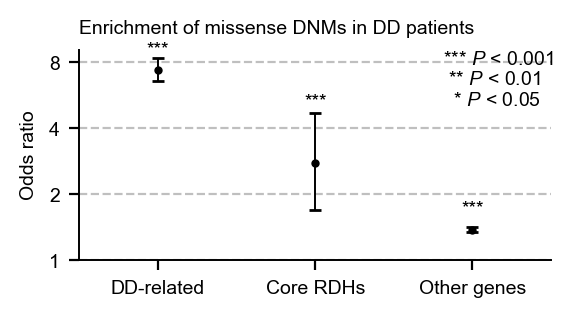

In [6]:
fig, ax = plt.subplots(figsize=(2.9, 1.6))


def get_significance(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


for i, row in plot_df.iterrows():

    xpos = i
    y = row["odds_ratio"]
    yerr = np.vstack([y - row["ci_low"], row["ci_high"] - y])

    ax.errorbar(
        xpos,
        y,
        yerr=yerr,
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=0.7,
        capsize=2,
        markersize=2,
        zorder=3,
    )

    # significance
    offset = 0.02 * (
        ax.get_ylim()[1] - ax.get_ylim()[0]
        if ax.get_ylim()[1] > ax.get_ylim()[0]
        else 1
    )
    sig = get_significance(row["p_value"])
    if sig:
        ax.text(
            xpos, row["ci_high"] + offset, sig, ha="center", va="bottom", fontsize=7
        )

# grid
ax.grid(True, linestyle="--", alpha=0.5, color="gray", zorder=0, axis="y")
ax.set_ylabel("Odds ratio")
ax.spines[["top", "right"]].set_visible(False)

# baseline
ax.set_yscale("log")
yticks = [1, 2, 4, 8]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticklabels(f"{i}" for i in yticks)
ax.set_xlim(-0.5, 2.5)
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.set_title("Enrichment of missense DNMs in DD patients", loc="left")
ax.set_xticks(
    [
        0,
        1,
        2,
    ]
)
ax.set_xticklabels(["DD-related", "Core RDHs", "Other genes"])
ax.text(
    s="*** $P$ < 0.001\n ** $P$ < 0.01\n  * $P$ < 0.05",
    x=0.77,
    y=1,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()

Family-level

In [7]:
df = pd.read_csv("data/RDH_all_possible_mis_syn_mutation_annotated.tsv", sep="\t")

In [8]:
mis_df = df[df["consequence"] == "nonsynonymous SNV"].copy()
syn_df = df[df["consequence"] == "synonymous SNV"].copy()

syn_DNM = syn_df["DD DNM count"].sum()
syn_ctrl = syn_df["is in gnomAD NFE"].sum()

rows = []
bin_count = 5
mis_df["bin"] = pd.qcut(mis_df["HistMTR"], q=bin_count, labels=False, duplicates="drop")

for bin_id, sub_df in mis_df.groupby("bin"):

    mis_DNM = sub_df["DD DNM count"].sum()
    mis_ctrl = sub_df["is in gnomAD NFE"].sum()

    result = run_r_fisher_test(mis_DNM, mis_ctrl, syn_DNM, syn_ctrl)
    threshold = sub_df["HistMTR"].max()
    rows.append(
        {
            "category": "HistMTR",
            "bin": int(bin_id) + 1,
            "threshold": threshold,
            "DD.mis": mis_DNM,
            "DD.syn": syn_DNM,
            "gnomAD.mis": mis_ctrl,
            "gnomAD.syn": syn_ctrl,
            **result,
        }
    )

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values(["category", "bin"]).reset_index(drop=True)
result_df["log2OR"] = np.log2(result_df["odds_ratio"])

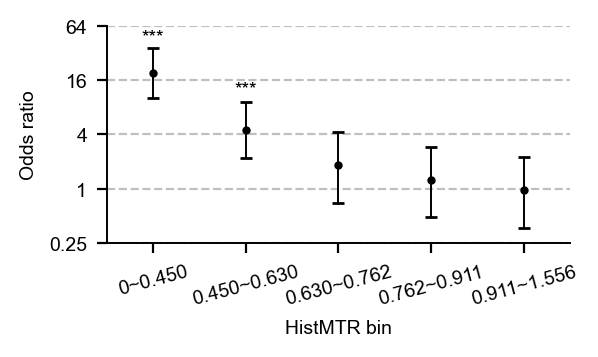

In [9]:
fig, ax = plt.subplots(figsize=(3, 1.8))

category_order = (
    result_df[result_df["bin"] == 1]
    .sort_values("odds_ratio", ascending=False)["category"]
    .tolist()
)

or_mat = result_df.pivot(index="bin", columns="category", values="odds_ratio").loc[
    :, category_order
]
low_mat = result_df.pivot(index="bin", columns="category", values="ci_low").loc[
    :, category_order
]
high_mat = result_df.pivot(index="bin", columns="category", values="ci_high").loc[
    :, category_order
]
p_mat = result_df.pivot(index="bin", columns="category", values="p_value").loc[
    :, category_order
]

bins = sorted(result_df["bin"].unique())
x = np.arange(len(bins))

n_hue = len(category_order)
group_width = 0.7
inner_gap = 0.15
bar_width = group_width / (n_hue + inner_gap * (n_hue - 1))


def get_significance(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


category_colors = {cat: "black" for cat in category_order}

for i, category in enumerate(category_order):

    xpos = (
        x - group_width / 2 + bar_width / 2 + i * bar_width + i * inner_gap * bar_width
    )

    y = or_mat[category].to_numpy()
    yerr = np.vstack(
        [y - low_mat[category].to_numpy(), high_mat[category].to_numpy() - y]
    )

    ax.errorbar(
        xpos,
        y,
        yerr=yerr,
        fmt="o",
        color=category_colors[category],
        ecolor=category_colors[category],
        elinewidth=0.7,
        capsize=2,
        markersize=2,
        zorder=3,
    )

    # significance
    offset = 0.02 * (
        ax.get_ylim()[1] - ax.get_ylim()[0]
        if ax.get_ylim()[1] > ax.get_ylim()[0]
        else 1
    )
    for xi, hi, p in zip(
        xpos, high_mat[category].to_numpy(), p_mat[category].to_numpy()
    ):
        sig = get_significance(p)
        if sig:
            ax.text(xi, hi + offset, sig, ha="center", va="bottom", fontsize=7)

# grid
ax.grid(True, linestyle="--", alpha=0.5, color="gray", zorder=0, axis="y")
ax.set_xlabel("HistMTR bin")
ax.set_ylabel("Odds ratio")
ax.spines[["top", "right"]].set_visible(False)

# x tick labels
xlabels = []
prev_value = 0
for _, row in result_df[result_df["category"] == category_order[0]].iterrows():
    if xlabels:
        xlabels.append(f"{prev_value:.3f}~{row['threshold']:.3f}")
    else:
        xlabels.append(f"{prev_value:.3g}~{row['threshold']:.3f}")
    prev_value = row["threshold"]

ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=15, ha="center")

# baseline
ax.set_yscale("log")
yticks = [0.25, 1, 4, 16, 64]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticklabels(f"{i}" for i in yticks)
ax.set_xlim(-0.5, 4.5)
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())

plt.tight_layout()